In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanrao/nifty50-stock-market-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nifty50-stock-market-data' dataset.
Path to dataset files: /kaggle/input/nifty50-stock-market-data


In [13]:
import os
print(os.listdir(path))

['HDFCBANK.csv', 'GRASIM.csv', 'WIPRO.csv', 'stock_metadata.csv', 'BPCL.csv', 'INFY.csv', 'LT.csv', 'RELIANCE.csv', 'BRITANNIA.csv', 'INFRATEL.csv', 'HEROMOTOCO.csv', 'HINDUNILVR.csv', 'TATAMOTORS.csv', 'MM.csv', 'HDFC.csv', 'JSWSTEEL.csv', 'TITAN.csv', 'HINDALCO.csv', 'AXISBANK.csv', 'HCLTECH.csv', 'ADANIPORTS.csv', 'GAIL.csv', 'NIFTY50_all.csv', 'BAJAJFINSV.csv', 'BAJFINANCE.csv', 'ICICIBANK.csv', 'ZEEL.csv', 'ASIANPAINT.csv', 'IOC.csv', 'TATASTEEL.csv', 'COALINDIA.csv', 'NESTLEIND.csv', 'DRREDDY.csv', 'ONGC.csv', 'EICHERMOT.csv', 'UPL.csv', 'SUNPHARMA.csv', 'ULTRACEMCO.csv', 'CIPLA.csv', 'SHREECEM.csv', 'VEDL.csv', 'TCS.csv', 'NTPC.csv', 'MARUTI.csv', 'KOTAKBANK.csv', 'ITC.csv', 'BAJAJ-AUTO.csv', 'SBIN.csv', 'INDUSINDBK.csv', 'BHARTIARTL.csv', 'TECHM.csv', 'POWERGRID.csv']


In [15]:
dataset_path = path  # change if needed

files = os.listdir(dataset_path)

print("Total Files:", len(files))
print(files[:10])

Total Files: 52
['HDFCBANK.csv', 'GRASIM.csv', 'WIPRO.csv', 'stock_metadata.csv', 'BPCL.csv', 'INFY.csv', 'LT.csv', 'RELIANCE.csv', 'BRITANNIA.csv', 'INFRATEL.csv']


In [17]:
import pandas as pd
import os

dataset_path = path

stock_data = []

for file in os.listdir(dataset_path):

    if file.endswith(".csv"):

        if file in ["stock_metadata.csv",
                    "NIFTY50_all.csv"]:
            continue

        df = pd.read_csv(os.path.join(dataset_path, file))

        df["Stock"] = file.replace(".csv","")

        stock_data.append(df)

all_data = pd.concat(stock_data, ignore_index=True)

print(all_data.shape)
all_data.head()

(235192, 16)


/tmp/ipykernel_1269/3533352137.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_data = pd.concat(stock_data, ignore_index=True)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Stock
0,2000-01-03,HDFCBANK,EQ,157.40,166.00,170.00,166.00,170.00,170.00,169.52,33259,5.638122e+11,NaN,NaN,NaN,HDFCBANK
1,2000-01-04,HDFCBANK,EQ,170.00,182.00,183.45,171.00,174.00,173.80,174.99,168710,2.952261e+12,NaN,NaN,NaN,HDFCBANK
2,2000-01-05,HDFCBANK,EQ,173.80,170.00,173.90,165.00,168.00,166.95,169.20,159820,2.704094e+12,NaN,NaN,NaN,HDFCBANK
3,2000-01-06,HDFCBANK,EQ,166.95,168.00,170.00,165.30,168.95,168.30,168.44,85026,1.432166e+12,NaN,NaN,NaN,HDFCBANK
4,2000-01-07,HDFCBANK,EQ,168.30,162.15,171.00,162.15,170.75,168.35,166.79,85144,1.420158e+12,NaN,NaN,NaN,HDFCBANK


In [18]:
print(all_data.columns)

Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble', 'Stock'],
      dtype='object')


In [19]:
all_data = all_data[['Date','Close','Stock']]

In [20]:
print(all_data.isnull().sum())

Date     0
Close    0
Stock    0
dtype: int64


In [21]:
all_data['Date'] = pd.to_datetime(all_data['Date'])

In [22]:
all_data = all_data.sort_values(
    ['Stock','Date']
)

In [23]:
all_data.head()

,Date,Close,Stock
93067,2007-11-27,962.90,ADANIPORTS
93068,2007-11-28,893.90,ADANIPORTS
93069,2007-11-29,884.20,ADANIPORTS
93070,2007-11-30,921.55,ADANIPORTS
93071,2007-12-03,969.30,ADANIPORTS


In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))


In [25]:
def create_sequences(data, window=30):

    X = []
    y = []

    for i in range(window, len(data)):

        X.append(data[i-window:i])

        y.append(data[i])

    return np.array(X), np.array(y)

In [26]:
X_all = []
y_all = []

In [27]:
stocks = all_data['Stock'].unique()

for stock in stocks:

    stock_df = all_data[
        all_data['Stock'] == stock
    ]

    prices = stock_df['Close'].values.reshape(-1,1)

    scaled_prices = scaler.fit_transform(prices)

    X, y = create_sequences(
        scaled_prices,
        window=30
    )

    X_all.append(X)
    y_all.append(y)

In [28]:
X_all = np.vstack(X_all)
y_all = np.vstack(y_all)
print(X_all.shape)
print(y_all.shape)

(233722, 30, 1)
(233722, 1)


In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42
)

In [30]:
print(X_train.shape)
print(X_test.shape)

(186977, 30, 1)
(46745, 30, 1)


In [31]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    SimpleRNN,
    Dense,
    Dropout
)

In [32]:
model = Sequential()

model.add(
    SimpleRNN(
        units=50,
        return_sequences=True,
        input_shape=(30,1)
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    SimpleRNN(
        units=50
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(25)
)

model.add(
    Dense(1)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,951 (34.96 KB)

 Trainable params: 8,951 (34.96 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=10,
    batch_size=64
)

Epoch 1/10
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 0.0034 - val_loss: 6.4368e-04
Epoch 2/10
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 7.7823e-04 - val_loss: 1.9557e-04
Epoch 3/10
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6.8555e-04 - val_loss: 4.8206e-04
Epoch 4/10
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 6.4974e-04 - val_loss: 1.4686e-04
Epoch 5/10
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 6.4752e-04 - val_loss: 1.4869e-04
Epoch 6/10
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6.4992e-04 - val_loss: 1.9815e-04
Epoch 7/10
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 6.2680e-04 - val_loss: 3.5012e-04
Epoch 8/10
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6.2870e-04 - val_loss: 2.5057e-04
Epoch 9/10
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 6.1382e-04 - val_loss: 1.6845e-04
Epoch 10/10
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 6.1108e-04 - val_loss: 3.5556e-04


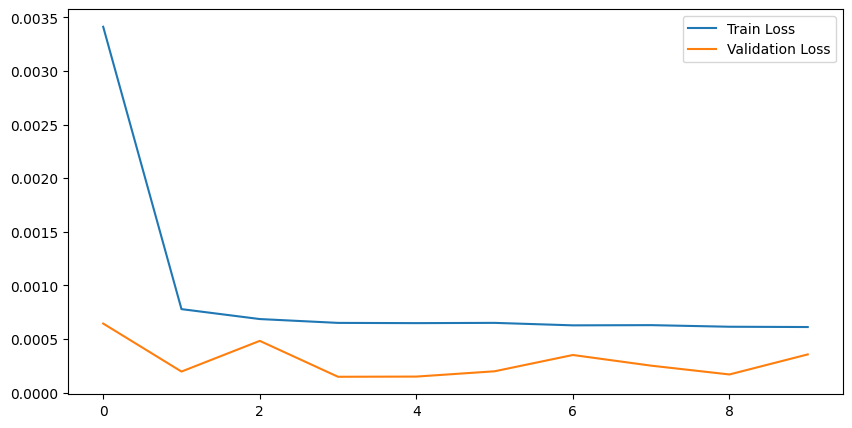

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()
plt.show()

In [37]:
predictions = model.predict(X_test)
print(predictions.shape)


1461/1461 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
(46745, 1)


In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.011592124829430436
RMSE: 0.018856332479560683
R2  : 0.9935910006644826


In [39]:
model.save("stock_rnn_model.h5")

In [40]:
from google.colab import files
files.download('stock_rnn_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
stocks = sorted(all_data['Stock'].unique())

print(len(stocks))
print(stocks[:10])

49
['ADANIPORTS', 'ASIANPAINT', 'AXISBANK', 'BAJAJ-AUTO', 'BAJAJFINSV', 'BAJFINANCE', 'BHARTIARTL', 'BPCL', 'BRITANNIA', 'CIPLA']


In [42]:
import pickle

with open("stocks.pkl", "wb") as f:
    pickle.dump(stocks, f)

In [44]:
stock_name = "TCS"
import pandas as pd

df = pd.read_csv(f"/kaggle/input/nifty50-stock-market-data/{stock_name}.csv")

df = df[['Close']]

df = df.dropna()
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df)
last_30 = scaled[-30:]
last_30.shape
X = last_30.reshape(1,30,1)
pred = model.predict(X)

pred_price = scaler.inverse_transform(pred)

print("Next Day Prediction:")
print(pred_price[0][0])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
Next Day Prediction:
2897.477
